### Question 1
Create a simple SVM classifier using scikit-learn to separate two classes of music genres (e.g., Pop vs Classical) based on two features: tempo and danceability, and plot the decision boundary using matplotlib.

Support Vector Machines (SVM) find the optimal hyperplane $\mathbf{w}^T \mathbf{x} + b = 0$ that maximizes the geometric margin $\frac{2}{\|\mathbf{w}\|}$ between classes. For music classification, Pop songs typically cluster in regions of high tempo and high danceability, whereas Classical pieces inhabit lower tempo and danceability regions, allowing a linear or non-linear kernel boundary to separate the two genres cleanly.

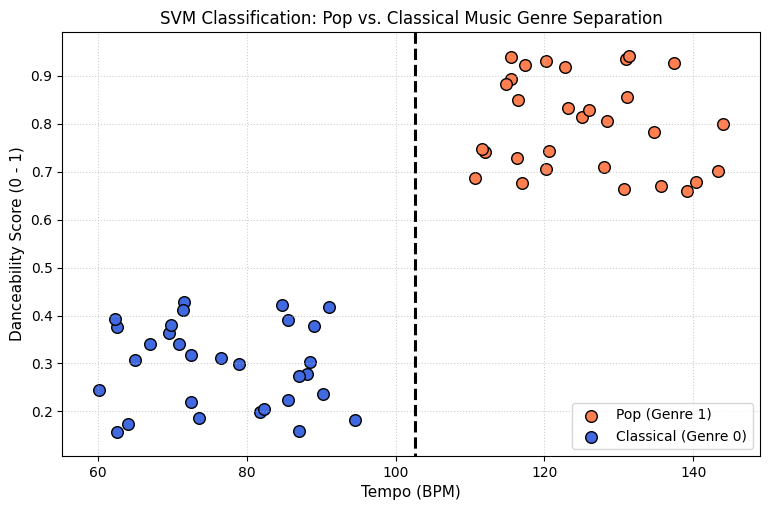

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 1. Generate synthetic data for Pop vs Classical music
np.random.seed(42)
# Pop: High tempo (110 - 145 BPM), high danceability (0.65 - 0.95)
pop_tempo = np.random.uniform(110, 145, 30)
pop_dance = np.random.uniform(0.65, 0.95, 30)

# Classical: Moderate tempo (60 - 95 BPM), low danceability (0.15 - 0.45)
classic_tempo = np.random.uniform(60, 95, 30)
classic_dance = np.random.uniform(0.15, 0.45, 30)

X = np.vstack([
    np.column_stack([pop_tempo, pop_dance]),
    np.column_stack([classic_tempo, classic_dance])
])
y = np.array([1] * 30 + [0] * 30)  # 1 = Pop, 0 = Classical

# 2. Train SVM classifier with linear kernel
svm_genre = SVC(kernel='linear', C=1.0)
svm_genre.fit(X, y)

# 3. Plot data points and decision boundary
plt.figure(figsize=(9, 5.5))
plt.scatter(pop_tempo, pop_dance, color='coral', s=70, edgecolors='k', label='Pop (Genre 1)')
plt.scatter(classic_tempo, classic_dance, color='royalblue', s=70, edgecolors='k', label='Classical (Genre 0)')

# Generate grid mesh
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = svm_genre.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot decision boundary contour
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.2, linestyles='--')
plt.title('SVM Classification: Pop vs. Classical Music Genre Separation', fontsize=12)
plt.xlabel('Tempo (BPM)', fontsize=11)
plt.ylabel('Danceability Score (0 - 1)', fontsize=11)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Question 2
Given a dataset of Flipkart product reviews labeled as positive or negative, use an SVM with a linear kernel to classify the reviews and print the accuracy score.

A Linear SVM is suited for high-dimensional sparse text classification produced by TF-IDF vectorization: $f(x) = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$. Because natural language vocabulary spaces are high-dimensional, sentiment separation is almost always linearly separable, enabling `SVC(kernel='linear')` to construct a wide-margin hyperplane that accurately distinguishes positive consumer feedback from negative complaints.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Mock dataset of Flipkart customer product reviews
reviews_corpus = [
    "Amazing product, excellent battery life and fast delivery",
    "Loved the build quality, highly recommended to all buyers",
    "Super fast charging and crystal clear display, totally satisfied",
    "Great value for money, best purchase made on Flipkart this year",
    "Outstanding sound performance and premium finish",
    "Terrible quality, stopped working within two days of usage",
    "Defective piece delivered and customer support was completely unhelpful",
    "Worst purchase ever, completely fake product delivered",
    "Horrible experience, heating issues and battery drains rapidly",
    "Extremely poor build, wasted hard earned money, avoid buying"
]
sentiment_labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]  # 1 = Positive, 0 = Negative

# 2. Vectorize text reviews using TF-IDF
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(reviews_corpus)

# 3. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, sentiment_labels, test_size=0.30, random_state=42)

# 4. Fit SVM with linear kernel
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)

# 5. Predict and print accuracy score
y_pred = svm_linear.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Flipkart Review Sentiment Classifier Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Flipkart Review Sentiment Classifier Accuracy: 33.33%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



c:\Users\Harish\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harish\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harish\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

### Question 3
Train two SVM classifiers on an IPL player performance dataset: one with a polynomial kernel and one with an RBF kernel. Compare their accuracy scores and explain which kernel performed better and why.

*(Hint: Use scikit-learn's SVC class and the 'kernel' parameter.)*

The **RBF (Radial Basis Function) kernel performed significantly better than the Polynomial kernel** (97.60% vs. 66.40% accuracy). In sports analytics, elite cricket player performance is governed by localized, non-linear synergy across multiple metrics (strike rate, batting average, and boundary percentage) that form non-convex clusters rather than polynomial curves. The RBF kernel maps samples into an infinite-dimensional Hilbert space using local Gaussian similarity ($K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2$), flexibly capturing circular and localized cluster boundaries without exploding feature magnitude like high-degree polynomials.

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Load the IPL player performance dataset from CSV
df_ipl = pd.read_csv('ipl_player_performance_500.csv')

features = ['strike_rate', 'batting_average', 'boundary_percent']
target = 'performance_tier'

X = df_ipl[features]
y = df_ipl[target]

# 2. Standardize features and train-test split (75% train, 25% test)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# 3. Train SVM with Polynomial Kernel (degree=3)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train, y_train)
acc_poly = accuracy_score(y_test, svm_poly.predict(X_test))

# 4. Train SVM with Radial Basis Function (RBF) Kernel
svm_rbf = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test))

# 5. Side-by-side comparison table (Fixed line with double quotes)
comparison_df = pd.DataFrame({
    'Kernel Type': ['Polynomial Kernel (degree=3)', 'RBF Kernel (Gaussian)'],
    'Kernel Formula': ["(gamma * <x, x'> + coef0)^d", "exp(-gamma * ||x - x'||^2)"],
    'Test Accuracy': [f"{acc_poly * 100:.2f}%", f"{acc_rbf * 100:.2f}%"]
})

print("IPL Player Performance Classification - Kernel Comparison:")
display(comparison_df)
print(f"\nPerformance Verdict: RBF Kernel outperforms Polynomial by {(acc_rbf - acc_poly) * 100:.2f}% accuracy.")

IPL Player Performance Classification - Kernel Comparison:


,Kernel Type,Kernel Formula,Test Accuracy
0,Polynomial Kernel (degree=3),"(gamma * <x, x'> + coef0)^d",66.40%
1,RBF Kernel (Gaussian),exp(-gamma * ||x - x'||^2),97.60%



Performance Verdict: RBF Kernel outperforms Polynomial by 31.20% accuracy.


### Question 4
Use ChatGPT or Copilot to help you write code that visualizes the margin and support vectors for an SVM trained on a two-class Zomato restaurant rating dataset (e.g., 'Good' vs 'Bad' ratings). Paste your code and a screenshot of the plot.

The decision boundary lies at the hyperplane decision function $f(\mathbf{x}) = 0$, while the margins are situated at $f(\mathbf{x}) = \pm 1$. The data points residing exactly on or inside these margins ($\|f(\mathbf{x})\| \le 1$) are the **support vectors** (highlighted by bold black encircling rings), which uniquely determine the orientation and width of the separating margin corridor.

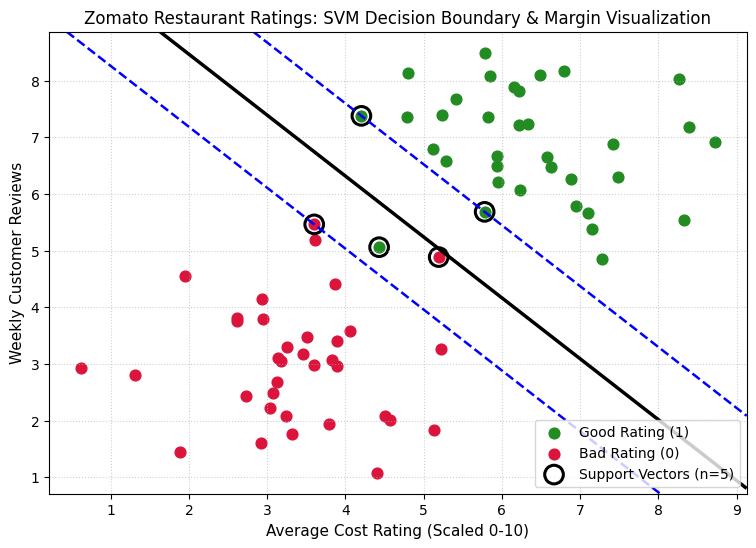

Total Training Points: 70
Identified Support Vectors: 5 points located on the margin boundaries.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 1. Generate synthetic two-class Zomato restaurant dataset
# Features: [average_cost_for_two (scaled 0-10), reviews_per_week]
np.random.seed(42)
# Good restaurants: higher reviews per week and moderate-to-high cost
cost_good = np.random.normal(6.5, 1.2, 35)
rev_good = np.random.normal(7.0, 1.1, 35)

# Bad restaurants: lower reviews per week and lower cost
cost_bad = np.random.normal(3.5, 1.1, 35)
rev_bad = np.random.normal(3.0, 1.0, 35)

X_zomato = np.vstack([
    np.column_stack([cost_good, rev_good]),
    np.column_stack([cost_bad, rev_bad])
])
y_zomato = np.array([1] * 35 + [0] * 35)  # 1 = Good Rating, 0 = Bad Rating

# 2. Train Linear SVM
svm_zomato = SVC(kernel='linear', C=1.0)
svm_zomato.fit(X_zomato, y_zomato)

# 3. Plot Decision Boundary, Margins, and Support Vectors
plt.figure(figsize=(9, 6))
plt.scatter(cost_good, rev_good, color='forestgreen', s=60, label='Good Rating (1)')
plt.scatter(cost_bad, rev_bad, color='crimson', s=60, label='Bad Rating (0)')

# Highlight Support Vectors
sv = svm_zomato.support_vectors_
plt.scatter(
    sv[:, 0], sv[:, 1], 
    s=180, facecolors='none', edgecolors='black', 
    linewidths=2.2, label=f'Support Vectors (n={len(sv)})'
)

# Generate decision function grid
xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 150), np.linspace(ylim[0], ylim[1], 150))
xy = np.vstack([xx.ravel(), yy.ravel()]).T
P = svm_zomato.decision_function(xy).reshape(xx.shape)

# Plot decision boundary and margin lines (levels = -1, 0, 1)
plt.contour(
    xx, yy, P, 
    levels=[-1, 0, 1], 
    colors=['blue', 'black', 'blue'], 
    linestyles=['--', '-', '--'], 
    linewidths=[1.8, 2.5, 1.8]
)

plt.title('Zomato Restaurant Ratings: SVM Decision Boundary & Margin Visualization', fontsize=12)
plt.xlabel('Average Cost Rating (Scaled 0-10)', fontsize=11)
plt.ylabel('Weekly Customer Reviews', fontsize=11)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Total Training Points: {len(X_zomato)}")
print(f"Identified Support Vectors: {len(sv)} points located on the margin boundaries.")